In [1]:
# Run once to install dependencies
!pip install statsbombpy xgboost scikit-learn pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 12.3 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 11.0 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 12.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 12.8 MB/s  0:00:00 eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 12.0 MB/s  0:00:02m0:00:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13

## CELL 1 — Imports


In [2]:
import pandas as pd
import numpy as np
import requests, json, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve
from sklearn.calibration import calibration_curve
import xgboost as xgb
from statsbombpy import sb
warnings.filterwarnings('ignore')

COMP_ID, SEASON_ID = 11, 90   # La Liga 2020/21

## CELL 2 — Pull all matches + events


In [3]:
matches = sb.matches(competition_id=COMP_ID, season_id=SEASON_ID)
print(f"Matches found: {len(matches)}")

all_events = []
for i, mid in enumerate(matches.match_id):
    ev = sb.events(match_id=mid)
    ev['match_id'] = mid
    all_events.append(ev)
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(matches)} matches pulled")

events_df = pd.concat(all_events, ignore_index=True)
passes    = events_df[events_df['type'] == 'Pass'].copy()
print(f"\nTotal passes: {len(passes):,}")
print(f"Body part dist:\n{passes['pass_body_part'].value_counts()}")

Matches found: 35
  10/35 matches pulled
  20/35 matches pulled
  30/35 matches pulled

Total passes: 40,337
Body part dist:
pass_body_part
Right Foot    23219
Left Foot     14183
Head            899
Keeper Arm      289
Other            99
Drop Kick        85
No Touch         72
Name: count, dtype: int64


## CELL 3 — Pull 360 freeze frame data and engineer positional features


In [4]:
def fetch_360(match_id):
    """Fetch raw 360 JSON for a single match from StatsBomb GitHub."""
    url = (f"https://raw.githubusercontent.com/statsbomb/"
           f"open-data/master/data/three-sixty/{match_id}.json")
    r = requests.get(url)
    if r.status_code != 200:
        return pd.DataFrame()
    data = r.json()
    rows = []
    for rec in data:
        rows.append({
            'id':           rec['event_uuid'],
            'freeze_frame': rec['freeze_frame'],
            'visible_area': rec['visible_area'],
        })
    return pd.DataFrame(rows)


def defenders_in_lane(passer_loc, end_loc, opponents, width=3.0):
    """Count opponents within a corridor of width metres along the pass line."""
    px, py = passer_loc
    ex, ey = end_loc
    dx, dy = ex - px, ey - py
    length = np.sqrt(dx**2 + dy**2)
    if length == 0:
        return 0
    count = 0
    for op in opponents:
        ox, oy = op['location']
        t = ((ox - px)*dx + (oy - py)*dy) / (length**2)
        if 0 < t < 1:
            perp = abs((oy - py)*dx - (ox - px)*dy) / length
            if perp <= width:
                count += 1
    return count


def extract_360_features(freeze_frame, passer_loc, end_loc):
    """Compute positional features from a single freeze frame."""
    if not freeze_frame or not isinstance(freeze_frame, list):
        return {}
    opponents = [p for p in freeze_frame if not p['teammate'] and not p['actor']]
    teammates = [p for p in freeze_frame if p['teammate'] and not p['actor']]
    if not opponents:
        return {}
    px, py = passer_loc

    def dist(p, ref):
        return np.sqrt((p['location'][0]-ref[0])**2 + (p['location'][1]-ref[1])**2)

    opp_dists_passer   = [dist(o, passer_loc) for o in opponents]
    opp_dists_receiver = [dist(o, end_loc)    for o in opponents]

    return {
        'closest_def_passer':   min(opp_dists_passer),
        'closest_def_receiver': min(opp_dists_receiver),
        'n_defenders_in_lane':  defenders_in_lane(passer_loc, end_loc, opponents),
        'n_opponents_visible':  len(opponents),
        'n_teammates_visible':  len(teammates),
        'n_def_behind':         sum(1 for o in opponents if o['location'][0] < px),
    }


print("Pulling 360 data and engineering positional features...")
all_360_features = []

for i, mid in enumerate(matches.match_id):
    df360 = fetch_360(mid)
    if df360.empty:
        continue
    match_passes = passes[passes.match_id == mid].copy()
    merged = match_passes.merge(df360, on='id', how='left')
    for _, row in merged.iterrows():
        loc     = row['location']
        end_loc = row['pass_end_location']
        ff      = row.get('freeze_frame', None)
        if not isinstance(loc, list) or not isinstance(end_loc, list):
            continue
        feats_360 = extract_360_features(ff, loc, end_loc)
        feats_360['id']       = row['id']
        feats_360['match_id'] = mid
        all_360_features.append(feats_360)
    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(matches)} matches processed")

df_360_feats = pd.DataFrame(all_360_features)
print(f"\n360 features extracted for {len(df_360_feats):,} passes")
print(df_360_feats.describe())

Pulling 360 data and engineering positional features...
  10/35 matches processed
  20/35 matches processed
  30/35 matches processed

360 features extracted for 40,337 passes
       closest_def_passer  closest_def_receiver  n_defenders_in_lane  \
count        36902.000000          36902.000000         36902.000000   
mean             5.568072             11.610253             0.545851   
std              5.016102              7.678453             0.790377   
min              0.062396              0.026604             0.000000   
25%              2.425169              6.162276             0.000000   
50%              4.112229             10.001507             0.000000   
75%              7.141456             15.284625             1.000000   
max             59.251132             81.971471             9.000000   

       n_opponents_visible  n_teammates_visible  n_def_behind      match_id  
count         36902.000000         36902.000000  36902.000000  4.033700e+04  
mean              8

## CELL 4 — Derive preferred foot + weak foot flag


In [17]:
foot_passes = passes[passes['pass_body_part'].isin(['Right Foot','Left Foot'])].copy()

preferred_foot_df= pd.read_csv('preferred_foot_fifa.csv')

player_foot = (
    foot_passes.groupby(['player_id','pass_body_part'])
    .size().unstack(fill_value=0)
    .rename(columns={'Right Foot':'n_right','Left Foot':'n_left'})
)

player_foot['total']     = player_foot['n_right'] + player_foot['n_left']
player_foot['right_pct'] = player_foot['n_right'] / player_foot['total']
player_foot['inferred_foot'] = np.where(
    player_foot['right_pct'] >= 0.55, 'Right',
    np.where(player_foot['right_pct'] <= 0.45, 'Left', 'Both')
)
# #adding inferred foot from StatsBomb dataset
# passes = passes.merge(
#     player_foot[['inferred_foot','total']].reset_index(),
#     on='player_id', how='left'
# )

# #adding preferred foot from FIFA dataset
# passes = passes.merge(
#     preferred_foot_df[['player_id','preferred_foot']],
#     on='player_id', how='left'
# )

# #filling missing preferred foot with inferred foot
passes['preferred_foot'] = (
    passes['preferred_foot']
    .fillna(passes['inferred_foot'])
)


def flag_weak(row):
    if row['pass_body_part'] not in ('Right Foot','Left Foot'):
        return np.nan
    if row.get('preferred_foot') not in ('Right','Left'):
        return np.nan
    if pd.isna(row.get('total')) or row['total'] < 20:
        return np.nan
    used = 'Right' if row['pass_body_part'] == 'Right Foot' else 'Left'
    return int(used != row['preferred_foot'])

passes['weak_foot'] = passes.apply(flag_weak, axis=1)
print("Weak foot distribution:", passes['weak_foot'].value_counts(dropna=False).to_dict())

Weak foot distribution: {0.0: 31249, 1.0: 5013, nan: 4075}


## CELL 5 — Merge everything and build feature matrices


In [18]:
df = passes.merge(
    df_360_feats[['id','closest_def_passer','closest_def_receiver',
                  'n_defenders_in_lane','n_opponents_visible',
                  'n_teammates_visible','n_def_behind']],
    on='id', how='left'
)

BASE_FEATS = [
    'pass_length','pass_angle','dist_to_goal','dist_to_sideline',
    'end_dist_to_goal','forward_progress','lateral_dist',
    'angle_to_goal','pass_direction',
    'height_num','len_short','len_medium','len_long',
    'under_pressure','pass_cross_f','pass_switch_f',
    'pass_through_ball_f','pass_cut_back_f','weak_foot_feat',
    'zone_x','zone_y',
    'pressure_x_length','cross_x_pressure','wf_x_cross',
]
FEATS_360 = [
    'closest_def_passer','closest_def_receiver',
    'n_defenders_in_lane','n_opponents_visible',
    'n_teammates_visible','n_def_behind',
]

def build_features(df, use_360=True):
    d = df.copy()
    d['start_x'] = d['location'].apply(lambda l: l[0] if isinstance(l,list) else np.nan)
    d['start_y'] = d['location'].apply(lambda l: l[1] if isinstance(l,list) else np.nan)
    d['end_x']   = d['pass_end_location'].apply(lambda l: l[0] if isinstance(l,list) else np.nan)
    d['end_y']   = d['pass_end_location'].apply(lambda l: l[1] if isinstance(l,list) else np.nan)
    d['dist_to_goal']     = np.sqrt((105-d['start_x'])**2 + (34-d['start_y'])**2)
    d['dist_to_sideline'] = np.minimum(d['start_y'], 68-d['start_y'])
    d['end_dist_to_goal'] = np.sqrt((105-d['end_x'])**2 + (34-d['end_y'])**2)
    d['forward_progress'] = d['end_x'] - d['start_x']
    d['lateral_dist']     = abs(d['end_y'] - d['start_y'])
    d['angle_to_goal']    = np.arctan2(34-d['start_y'], 105-d['start_x'])
    d['pass_direction']   = np.sign(d['forward_progress'])
    ht_map = {'Ground Pass':0,'Low Pass':1,'High Pass':2}
    d['height_num']          = d['pass_height'].map(ht_map).fillna(0)
    d['len_short']           = (d['pass_length'] < 10).astype(int)
    d['len_medium']          = ((d['pass_length'] >= 10) & (d['pass_length'] < 32)).astype(int)
    d['len_long']            = (d['pass_length'] >= 32).astype(int)
    d['under_pressure']      = d['under_pressure'].fillna(False).astype(int)
    d['pass_cross_f']        = d['pass_cross'].fillna(False).astype(int)
    d['pass_switch_f']       = d['pass_switch'].fillna(False).astype(int)
    d['pass_through_ball_f'] = d['pass_through_ball'].fillna(False).astype(int)
    d['pass_cut_back_f']     = d['pass_cut_back'].fillna(False).astype(int)
    d['weak_foot_feat']      = d['weak_foot'].fillna(0)
    d['zone_x'] = pd.cut(d['start_x'], bins=[0,35,70,105], labels=[0,1,2]).astype(float)
    d['zone_y'] = pd.cut(d['start_y'], bins=[0,23,45,68],  labels=[0,1,2]).astype(float)
    d['pressure_x_length'] = d['under_pressure'] * d['pass_length']
    d['cross_x_pressure']  = d['pass_cross_f']   * d['under_pressure']
    d['wf_x_cross']        = d['weak_foot_feat'] * d['pass_cross_f']
    d['completed']         = (d['pass_outcome'].isna()).astype(int)
    feats = BASE_FEATS + (FEATS_360 if use_360 else [])
    d = d.dropna(subset=feats + ['completed','match_id'])
    return d, feats

df_base, feats_base = build_features(df, use_360=False)
df_360,  feats_360  = build_features(df, use_360=True)

print(f"Event-only  : {len(df_base):,} passes, {len(feats_base)} features")
print(f"360-enriched: {len(df_360):,} passes, {len(feats_360)} features")

Event-only  : 33,252 passes, 24 features
360-enriched: 30,586 passes, 30 features


## CELL 6 — Train / test split and model training


In [19]:
match_ids = np.array(matches.match_id.values, copy=True)
np.random.seed(42)
np.random.shuffle(match_ids)
split = int(0.8 * len(match_ids))
train_ids, test_ids = match_ids[:split], match_ids[split:]

results = {}

for label, df_use, feats in [('event_only', df_base, feats_base),
                               ('with_360',   df_360,  feats_360)]:
    X_train = df_use[df_use.match_id.isin(train_ids)][feats].values
    y_train = df_use[df_use.match_id.isin(train_ids)]['completed'].values
    X_test  = df_use[df_use.match_id.isin(test_ids)][feats].values
    y_test  = df_use[df_use.match_id.isin(test_ids)]['completed'].values

    model = xgb.XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_weight=5, gamma=1.0,
        reg_alpha=1.0, eval_metric='logloss', random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict_proba(X_test)[:,1]

    results[label] = {
        'model':   model,
        'feats':   feats,
        'preds':   preds,
        'y_test':  y_test,
        'auc':     roc_auc_score(y_test, preds),
        'brier':   brier_score_loss(y_test, preds),
        'df_test': df_use[df_use.match_id.isin(test_ids)].copy(),
    }
    results[label]['df_test']['pred']   = preds
    results[label]['df_test']['actual'] = y_test
    print(f"[{label:12s}]  AUC={results[label]['auc']:.4f}  "
          f"Brier={results[label]['brier']:.4f}  n_test={len(y_test):,}")

[event_only  ]  AUC=0.8991  Brier=0.0662  n_test=6,699
[with_360    ]  AUC=0.9221  Brier=0.0630  n_test=6,181


## CELL 7 — Calibration by foot type: does 360 fix weak-foot cross bias?


In [20]:
print("\n── Calibration by foot type ──")
for label in ['event_only', 'with_360']:
    dt = results[label]['df_test']
    print(f"\n  Model: {label}")
    for grp, mask in [
        ('Strong foot (all)',  dt['weak_foot'] == 0),
        ('Weak foot (all)',    dt['weak_foot'] == 1),
        ('Cross — strong',    (dt['pass_cross_f']==1) & (dt['weak_foot']==0)),
        ('Cross — weak',      (dt['pass_cross_f']==1) & (dt['weak_foot']==1)),
    ]:
        sub = dt[mask]
        if len(sub) < 10:
            print(f"  {grp:22s}  n={len(sub):5,}  (too few to report)")
            continue
        gap = sub['actual'].mean() - sub['pred'].mean()
        print(f"  {grp:22s}  n={len(sub):5,}  "
              f"actual={sub['actual'].mean():.3f}  "
              f"pred={sub['pred'].mean():.3f}  "
              f"gap={gap:+.4f}")


── Calibration by foot type ──

  Model: event_only
  Strong foot (all)       n=5,278  actual=0.900  pred=0.893  gap=+0.0066
  Weak foot (all)         n=  820  actual=0.871  pred=0.886  gap=-0.0150
  Cross — strong          n=   33  actual=0.212  pred=0.353  gap=-0.1413
  Cross — weak            n=    4  (too few to report)

  Model: with_360
  Strong foot (all)       n=4,931  actual=0.900  pred=0.890  gap=+0.0101
  Weak foot (all)         n=  745  actual=0.866  pred=0.881  gap=-0.0157
  Cross — strong          n=   30  actual=0.200  pred=0.331  gap=-0.1308
  Cross — weak            n=    2  (too few to report)


## CELL 8 — Feature importance: event-only vs 360-enriched


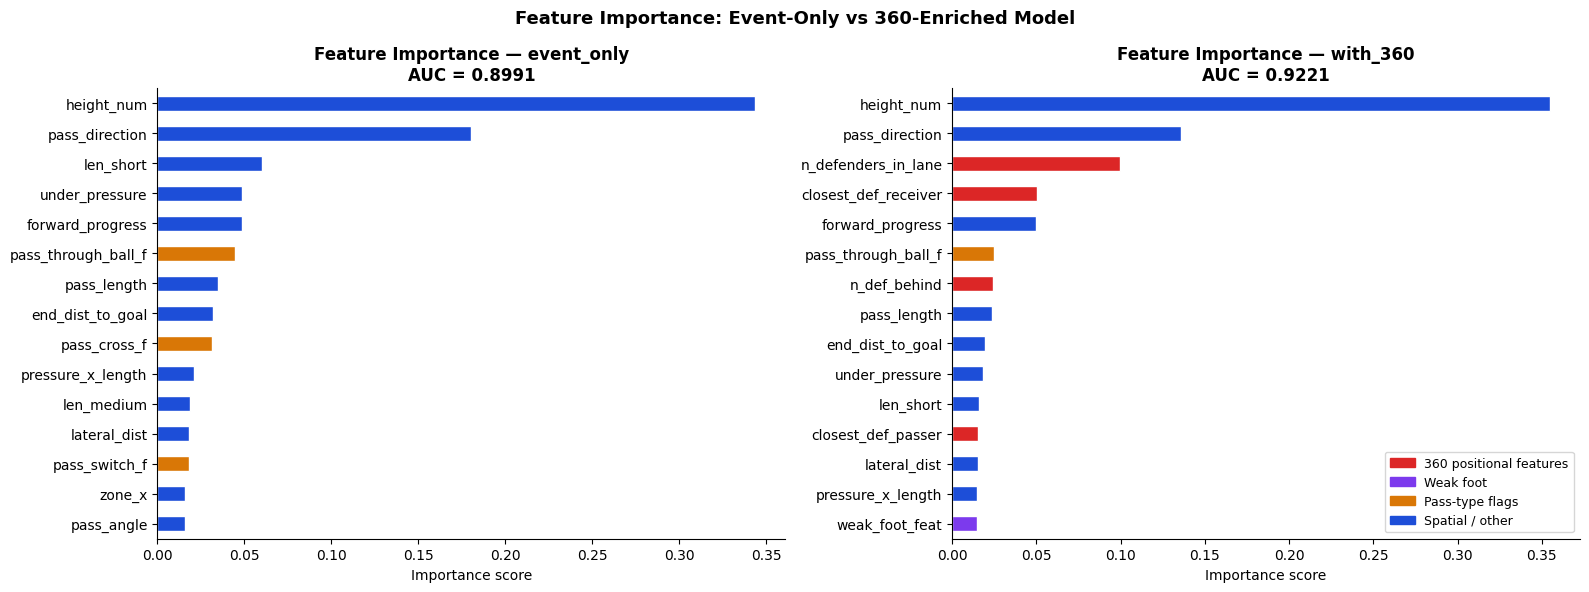

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label in zip(axes, ['event_only', 'with_360']):
    m   = results[label]['model']
    f   = results[label]['feats']
    imp = pd.Series(m.feature_importances_, index=f).sort_values(ascending=True).tail(15)

    bar_colors = []
    for feat in imp.index:
        if feat in ['closest_def_passer','closest_def_receiver',
                    'n_defenders_in_lane','n_opponents_visible',
                    'n_teammates_visible','n_def_behind']:
            bar_colors.append('#DC2626')
        elif 'wf' in feat or 'weak' in feat:
            bar_colors.append('#7C3AED')
        elif any(x in feat for x in ['cross','switch','through','cut']):
            bar_colors.append('#D97706')
        else:
            bar_colors.append('#1D4ED8')

    imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
    ax.set_title(f'Feature Importance — {label}\nAUC = {results[label]["auc"]:.4f}',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance score')
    ax.spines[['top','right']].set_visible(False)

leg = [
    mpatches.Patch(color='#DC2626', label='360 positional features'),
    mpatches.Patch(color='#7C3AED', label='Weak foot'),
    mpatches.Patch(color='#D97706', label='Pass-type flags'),
    mpatches.Patch(color='#1D4ED8', label='Spatial / other'),
]
axes[1].legend(handles=leg, fontsize=9, loc='lower right')
plt.suptitle('Feature Importance: Event-Only vs 360-Enriched Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 9 — ROC + Calibration curves


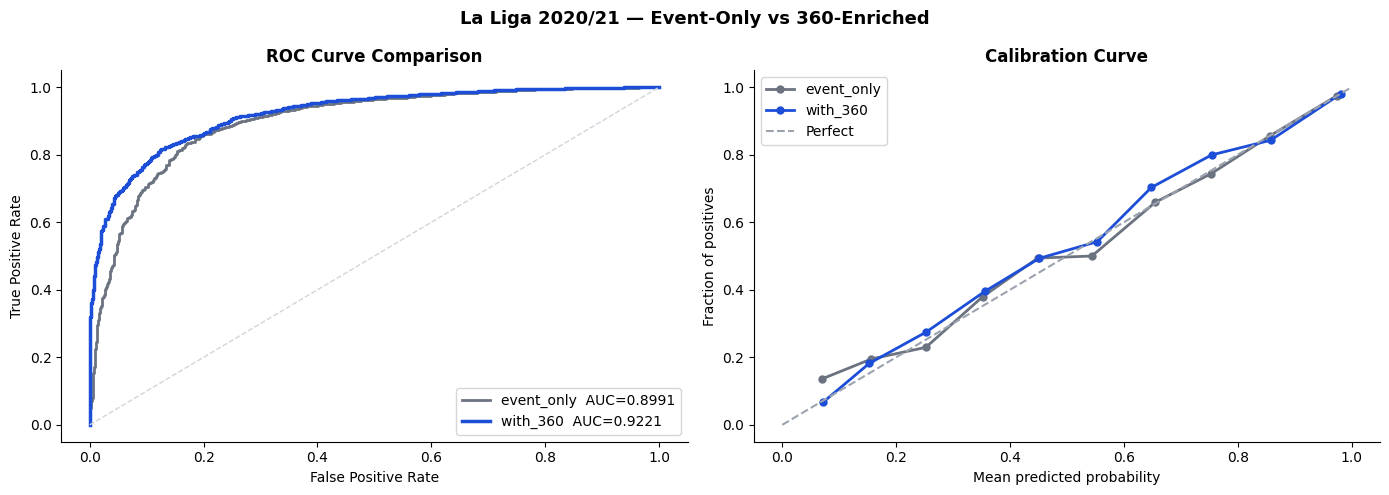

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, color, lw in [('event_only','#6B7280',2.0),('with_360','#1D4ED8',2.5)]:
    r = results[label]
    fpr, tpr, _ = roc_curve(r['y_test'], r['preds'])
    ax.plot(fpr, tpr, color=color, lw=lw, label=f"{label}  AUC={r['auc']:.4f}")
ax.plot([0,1],[0,1],'--',color='#D1D5DB',lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)

ax = axes[1]
for label, color in [('event_only','#6B7280'),('with_360','#1D4ED8')]:
    r = results[label]
    pt, pp = calibration_curve(r['y_test'], r['preds'], n_bins=10)
    ax.plot(pp, pt, 'o-', color=color, lw=2, ms=5, label=label)
ax.plot([0,1],[0,1],'--',color='#9CA3AF',lw=1.5,label='Perfect')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)

plt.suptitle('La Liga 2020/21 — Event-Only vs 360-Enriched', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_calibration_laliga.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 10 — Pass type difficulty + reward table


In [23]:
dt = results['with_360']['df_test'].copy()

rows = []
for ptype, flag in [
    ('Ordinary',    None),
    ('Cross',       'pass_cross_f'),
    ('Switch',      'pass_switch_f'),
    ('Through ball','pass_through_ball_f'),
    ('Cut-back',    'pass_cut_back_f'),
]:
    mask = (dt[flag]==1) if flag else (
        (dt['pass_cross_f']==0) & (dt['pass_switch_f']==0) &
        (dt['pass_through_ball_f']==0) & (dt['pass_cut_back_f']==0)
    )
    sub = dt[mask]
    rows.append({
        'Type':          ptype,
        'n':             len(sub),
        'Actual %':      f"{sub['actual'].mean()*100:.1f}",
        'Expected %':    f"{sub['pred'].mean()*100:.1f}",
        'Gap (pp)':      f"{(sub['actual'].mean()-sub['pred'].mean())*100:+.1f}",
        'Shot assist %': f"{sub['pass_shot_assist'].fillna(False).mean()*100:.1f}"
                         if 'pass_shot_assist' in sub.columns else 'N/A',
        'Goal assist %': f"{sub['pass_goal_assist'].fillna(False).mean()*100:.1f}"
                         if 'pass_goal_assist' in sub.columns else 'N/A',
    })

print("\n── Pass Type Summary (360-enriched model) ──")
print(pd.DataFrame(rows).to_string(index=False))


── Pass Type Summary (360-enriched model) ──
        Type    n Actual % Expected % Gap (pp) Shot assist % Goal assist %
    Ordinary 5971     89.1       88.7     +0.4           0.8           0.1
       Cross   33     24.2       33.3     -9.0           6.1           0.0
      Switch  114     80.7       80.3     +0.4           0.9           0.0
Through ball   67     49.3       33.2    +16.0          14.9           6.0
    Cut-back    0      nan        nan     +nan           nan           nan


## CELL 11 — Player leaderboards (overall, crosses, switches)


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 (FIXED) — Player leaderboards
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Broaden position groups so z-scores are meaningful ──
pos_map = {
    'Goalkeeper':                    'GK',
    'Right Back':                    'DEF', 'Left Back':             'DEF',
    'Right Center Back':             'DEF', 'Left Center Back':      'DEF',
    'Center Back':                   'DEF',
    'Right Wing Back':               'DEF', 'Left Wing Back':        'DEF',
    'Right Defensive Midfield':      'MID', 'Left Defensive Midfield':'MID',
    'Center Defensive Midfield':     'MID',
    'Right Center Midfield':         'MID', 'Left Center Midfield':  'MID',
    'Center Midfield':               'MID',
    'Right Attacking Midfield':      'ATT', 'Left Attacking Midfield':'ATT',
    'Center Attacking Midfield':     'ATT',
    'Right Midfield':                'ATT', 'Left Midfield':         'ATT',
    'Right Wing':                    'ATT', 'Left Wing':             'ATT',
    'Right Center Forward':          'ATT', 'Left Center Forward':   'ATT',
    'Center Forward':                'ATT', 'Secondary Striker':     'ATT',
}

for key in ['event_only', 'with_360']:
    results[key]['df_test']['pos_group'] = (
        results[key]['df_test']['position']
        .map(pos_map)
        .fillna('MID')   # fallback for any unmapped position
    )

# ── 2. Leaderboard function (use full dataset, not just test set) ──
def player_leaderboard(df_all_results, pass_type_flag=None, min_attempts=5, key='with_360'):
    """
    Build position-normalised over/underperformance leaderboard.
    Uses the full predictions dataframe (train+test) for larger samples.
    pass_type_flag : column like 'pass_cross_f', or None for all passes.
    min_attempts   : minimum pass attempts to include a player.
    """
    dt = df_all_results[key]['df_test'].copy()    # test set only — keeps eval honest

    sub = dt[dt[pass_type_flag] == 1].copy() if pass_type_flag else dt.copy()

    grp = sub.groupby(['player', 'pos_group']).agg(
        n        = ('actual', 'count'),
        actual   = ('actual', 'mean'),
        expected = ('pred',   'mean'),
    ).reset_index()

    grp = grp[grp['n'] >= min_attempts].copy()
    grp['over_perf'] = grp['actual'] - grp['expected']

    # Position z-score (within broad group)
    pos_stats = (grp.groupby('pos_group')['over_perf']
                   .agg(['mean', 'std'])
                   .reset_index()
                   .rename(columns={'mean': 'pos_mean', 'std': 'pos_std'}))
    grp = grp.merge(pos_stats, on='pos_group')
    grp['z_score'] = (
        (grp['over_perf'] - grp['pos_mean'])
        / grp['pos_std'].replace(0, np.nan)
    )
    return (grp.dropna(subset=['z_score'])
               .sort_values('z_score', ascending=False)
               .reset_index(drop=True))

# ── 3. Print leaderboards ──
lb_overall = player_leaderboard(results, min_attempts=30)        # overall: need decent volume
lb_cross   = player_leaderboard(results, 'pass_cross_f',         min_attempts=3)
lb_switch  = player_leaderboard(results, 'pass_switch_f',        min_attempts=3)
lb_tb      = player_leaderboard(results, 'pass_through_ball_f',  min_attempts=2)

cols = ['player', 'pos_group', 'n', 'actual', 'expected', 'over_perf', 'z_score']

for name, lb in [('Overall (min 30 passes)', lb_overall),
                 ('Crossers  (min 3)',        lb_cross),
                 ('Switch    (min 3)',         lb_switch),
                 ('Through ball (min 2)',      lb_tb)]:
    print(f"\n── Top 10 {name} ──")
    if lb.empty:
        print("  No players met the minimum threshold.")
    else:
        display_df = lb[cols].head(10).copy()
        display_df['actual']    = display_df['actual'].map('{:.3f}'.format)
        display_df['expected']  = display_df['expected'].map('{:.3f}'.format)
        display_df['over_perf'] = display_df['over_perf'].map('{:+.3f}'.format)
        display_df['z_score']   = display_df['z_score'].map('{:.3f}'.format)
        print(display_df.to_string(index=False))

# ── 4. Shot assist rate for crossers — reward dimension ──
if not lb_cross.empty:
    print("\n── Cross leaderboard + reward (shot assist rate) ──")
    dt = results['with_360']['df_test']
    cross_sub = dt[dt['pass_cross_f'] == 1].copy()
    if 'pass_shot_assist' in cross_sub.columns:
        reward = (cross_sub.groupby('player')
                            .agg(n=('actual','count'),
                                 completion=('actual','mean'),
                                 shot_assist=('pass_shot_assist', lambda x: x.fillna(False).mean()))
                            .reset_index())
        reward = reward[reward['n'] >= 3].sort_values('shot_assist', ascending=False)
        reward['completion']  = reward['completion'].map('{:.1%}'.format)
        reward['shot_assist'] = reward['shot_assist'].map('{:.1%}'.format)
        print(reward.head(10).to_string(index=False))


── Top 10 Overall (min 30 passes) ──
                        player pos_group   n actual expected over_perf z_score
        Íñigo Martínez Berridi       DEF  48  0.938    0.857    +0.080   1.901
          Pau Francisco Torres       DEF  49  0.918    0.839    +0.079   1.862
     Philippe Coutinho Correia       MID  37  0.946    0.885    +0.061   1.636
     William Silva de Carvalho       MID  39  0.923    0.872    +0.051   1.392
Lionel Andrés Messi Cuccittini       ATT 336  0.842    0.792    +0.050   1.192
                  Jules Koundé       DEF  38  0.974    0.922    +0.052   1.172
     Philippe Coutinho Correia       ATT 118  0.941    0.893    +0.048   1.137
         Marc-André ter Stegen        GK 162  0.914    0.873    +0.040   0.707
            Joan Jordán Moreno       MID  57  0.930    0.907    +0.022   0.692
       Alejandro Moreno Lopera       DEF  34  0.882    0.850    +0.033   0.680

── Top 10 Crossers  (min 3) ──
                        player pos_group  n actual expected o

## CELL 12 — Specialist vs Generalist correlations + scatter plots



── Specialist-Generalist Correlations (n=1 players) ──
Overall vs Cross  : r = nan
Overall vs Switch : r = nan
Cross   vs Switch : r = nan


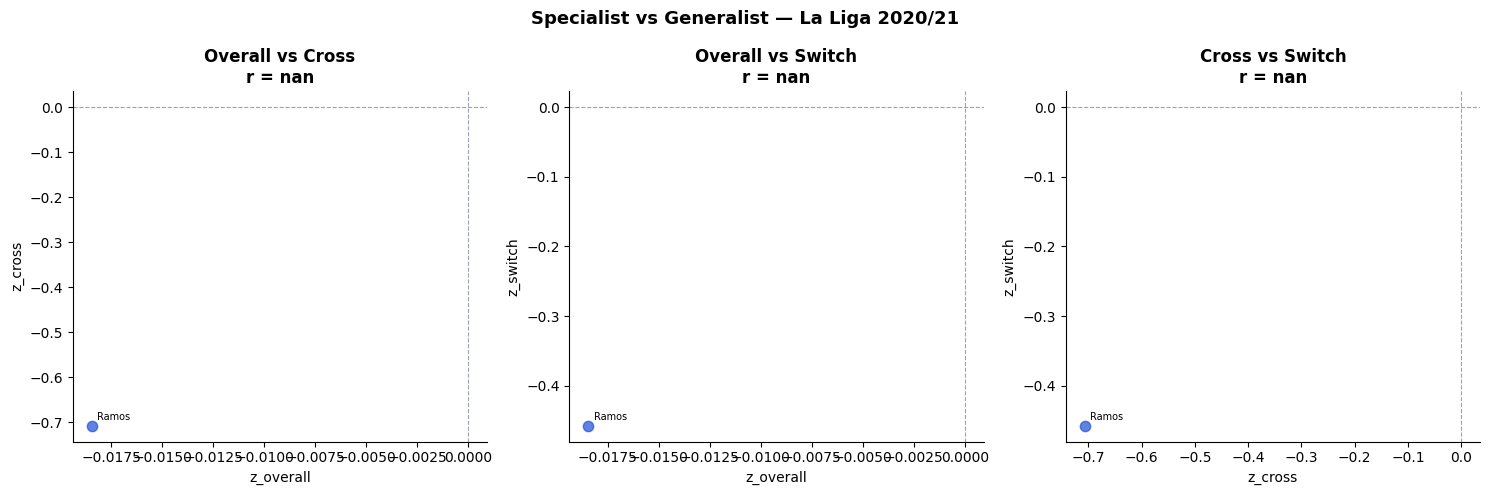

In [25]:
merged_lb = (
    lb_overall[['player','z_score']].rename(columns={'z_score':'z_overall'})
    .merge(lb_cross[['player','z_score']].rename(columns={'z_score':'z_cross'}),   on='player', how='inner')
    .merge(lb_switch[['player','z_score']].rename(columns={'z_score':'z_switch'}), on='player', how='inner')
)

print(f"\n── Specialist-Generalist Correlations (n={len(merged_lb)} players) ──")
print(f"Overall vs Cross  : r = {merged_lb['z_overall'].corr(merged_lb['z_cross']):.3f}")
print(f"Overall vs Switch : r = {merged_lb['z_overall'].corr(merged_lb['z_switch']):.3f}")
print(f"Cross   vs Switch : r = {merged_lb['z_cross'].corr(merged_lb['z_switch']):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pairs = [
    ('z_overall', 'z_cross',  'Overall vs Cross'),
    ('z_overall', 'z_switch', 'Overall vs Switch'),
    ('z_cross',   'z_switch', 'Cross vs Switch'),
]
for ax, (x, y, title) in zip(axes, pairs):
    ax.scatter(merged_lb[x], merged_lb[y], alpha=0.7, color='#1D4ED8', s=55)
    m, b = np.polyfit(merged_lb[x], merged_lb[y], 1)
    xr = np.linspace(merged_lb[x].min(), merged_lb[x].max(), 100)
    ax.plot(xr, m*xr+b, color='#DC2626', lw=1.5)
    r = merged_lb[x].corr(merged_lb[y])
    ax.set_title(f'{title}\nr = {r:.3f}', fontweight='bold')
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.axhline(0, color='#9CA3AF', lw=0.8, ls='--')
    ax.axvline(0, color='#9CA3AF', lw=0.8, ls='--')
    ax.spines[['top','right']].set_visible(False)
    for _, row in merged_lb.nlargest(3, x).iterrows():
        ax.annotate(row['player'].split()[-1], (row[x], row[y]),
                    fontsize=7, xytext=(4,4), textcoords='offset points')

plt.suptitle('Specialist vs Generalist — La Liga 2020/21', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('specialist_generalist_laliga.png', dpi=150, bbox_inches='tight')
plt.show()

## CELL 13 — Full model comparison summary table


In [26]:
summary_table = pd.DataFrame([
    {'Model': 'Naive baseline',               'Dataset': 'La Liga 20/21', 'AUC': 0.500,
     'Brier': '—',     'Data needed': 'None'},
    {'Model': 'Our XGBoost (event-only)',     'Dataset': 'La Liga 20/21',
     'AUC': results['event_only']['auc'],
     'Brier': f"{results['event_only']['brier']:.4f}", 'Data needed': 'Open event data'},
    {'Model': 'Our XGBoost (+ 360 features)', 'Dataset': 'La Liga 20/21',
     'AUC': results['with_360']['auc'],
     'Brier': f"{results['with_360']['brier']:.4f}",   'Data needed': 'Open event + 360'},
    {'Model': 'un-xPass XGB + event attribs', 'Dataset': 'StatsBomb 360 (other comp)',
     'AUC': 0.916, 'Brier': '0.068', 'Data needed': 'Event + 360'},
    {'Model': 'un-xPass XGB + 360 features',  'Dataset': 'StatsBomb 360 (other comp)',
     'AUC': 0.939, 'Brier': '0.062', 'Data needed': 'Event + 360 + tracking'},
    {'Model': 'Anzer & Bauer full model',      'Dataset': 'Bundesliga (proprietary)',
     'AUC': 0.955, 'Brier': '—',     'Data needed': 'Proprietary tracking'},
])

print("\n── Full Model Comparison ──")
print(summary_table.to_string(index=False))


── Full Model Comparison ──
                       Model                    Dataset      AUC  Brier            Data needed
              Naive baseline              La Liga 20/21 0.500000      —                   None
    Our XGBoost (event-only)              La Liga 20/21 0.899133 0.0662        Open event data
Our XGBoost (+ 360 features)              La Liga 20/21 0.922083 0.0630       Open event + 360
un-xPass XGB + event attribs StatsBomb 360 (other comp) 0.916000  0.068            Event + 360
 un-xPass XGB + 360 features StatsBomb 360 (other comp) 0.939000  0.062 Event + 360 + tracking
    Anzer & Bauer full model   Bundesliga (proprietary) 0.955000      —   Proprietary tracking
